# Predicción de churn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [2]:
features_path = "clustering_dataset.csv"
X = pd.read_csv(features_path, index_col=0)

In [3]:
### Construcción del target de churn

In [4]:
transactions_path = "eda_dataset.csv"
df = pd.read_csv(transactions_path, parse_dates=["InvoiceDate"])

“El target de churn se construye directamente a partir de las transacciones limpias, mientras que las features y los clusters provienen de un pipeline independiente basado exclusivamente en la ventana de observación.”

In [5]:
PRED_START = pd.Timestamp("2011-09-01")
PRED_END = pd.Timestamp("2011-12-09")

df_pred = df[
    (df["InvoiceDate"] >= PRED_START) &
    (df["InvoiceDate"] <= PRED_END)
]


In [6]:
active_customers = (
    df_pred["CustomerID"]
    .unique()
)


In [7]:
# Definición Churn
X["churn"] = (~X.index.isin(active_customers)).astype(int)
X["churn"].value_counts(normalize=True)
# Suele producir un dataset resbalanceado

churn
0    0.589568
1    0.410432
Name: proportion, dtype: float64

In [8]:
# Separación X/y
y = X["churn"]
X_model = X.drop(columns=["churn"])


In [9]:
# Cluster como feature categórica
X_model["cluster"] = X_model["cluster"].astype("category")
X_model = pd.get_dummies(X_model, drop_first=True)


### Train / Test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


### Modelo baseline — Logistic Regression

In [11]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [12]:
y_pred_prob = log_reg.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_pred_prob)


0.7176975566806075

In [13]:
print(
    classification_report(
        y_test,
        (y_pred_prob > 0.5).astype(int)
    )
)


              precision    recall  f1-score   support

           0       0.73      0.62      0.67       594
           1       0.55      0.67      0.61       413

    accuracy                           0.64      1007
   macro avg       0.64      0.65      0.64      1007
weighted avg       0.66      0.64      0.65      1007



### Modelo no lineal — Random Forest

In [14]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [15]:
y_pred_prob_rf = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_pred_prob_rf)


0.7076862246353771

### Impacto del clustering (análisis clave)

In [16]:
X_no_cluster = X_model.drop(
    columns=[col for col in X_model.columns if "cluster_" in col]
)

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_cluster,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

log_reg_nc = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg_nc.fit(X_train_nc, y_train_nc)

roc_auc_score(
    y_test_nc,
    log_reg_nc.predict_proba(X_test_nc)[:,1]
)


0.7178932178932178

### Interpretabilidad — Importancia de variables

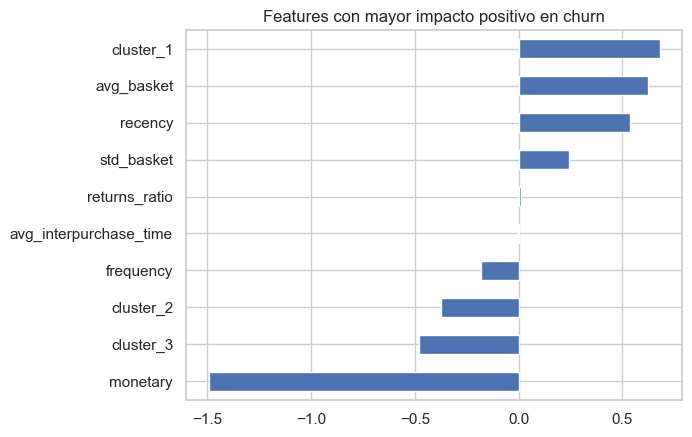

In [17]:
coef = pd.Series(
    log_reg.coef_[0],
    index=X_model.columns
).sort_values()

coef.tail(10).plot(kind="barh")
plt.title("Features con mayor impacto positivo en churn")
plt.show()


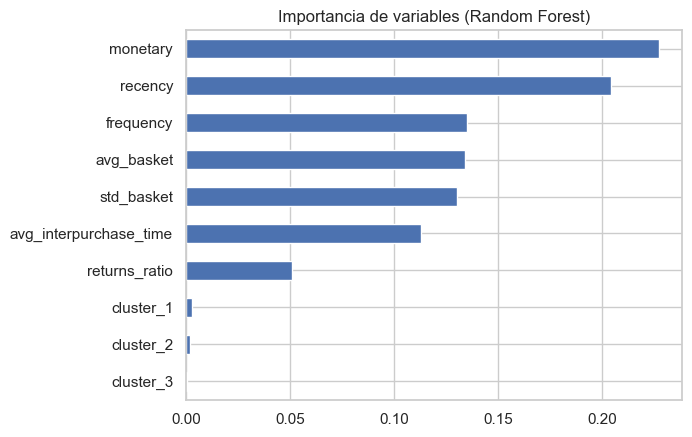

In [18]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_model.columns
).sort_values()

importances.tail(10).plot(kind="barh")
plt.title("Importancia de variables (Random Forest)")
plt.show()


“La recency y el cluster de clientes inactivos son los principales predictores de churn.”